# Phishing Website Detection - Reproduction Study

This notebook reproduces and evaluates the GitHub project "URL-Based Phishing Detection Using Machine Learning".

The goal is to verify the author's findings, examine the dataset, evaluate the preprocessing steps, and reproduce the machine learning results.

In [4]:
import pandas as pd

df = pd.read_csv("phishing.csv")
df.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


## Data Loading and Initial Inspection

In [6]:
import pandas as pd

df = pd.read_csv("phishing.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (11054, 32)


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


## Dataset Information

In [7]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (11054, 32)

Column Names:
['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport', 'class']

Data Types:
Index                  int64
UsingIP                int64
LongURL                int64
ShortURL               int64
Symbol@                int64
Redirecting//          int64
PrefixSuffix-          int64
SubDomains             int64
HTTPS                  int64
DomainRegLen           int64
Favicon                int64
NonStdPort             int64
HTTPSDomainURL         int64
RequestURL             int64
AnchorURL              int64
LinksInScriptTags  

### Dataset Structure Analysis

The dataset contains 11,054 observations and 32 columns. All features are stored as integer values, indicating that no additional encoding is required before model training.

The column named "Index" appears to function only as a row identifier rather than a meaningful cybersecurity feature. Since it does not contain predictive information about whether a website is phishing or legitimate, it should be removed before model training to avoid introducing unnecessary noise into the analysis.

In [8]:
df = df.drop("Index", axis=1)

print("Dataset Shape After Removing Index:", df.shape)

Dataset Shape After Removing Index: (11054, 31)


## Missing Values and Duplicate Records

This section checks whether the dataset contains missing values or duplicate rows before model training.

In [9]:
missing_values = df.isnull().sum()
missing_values

UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL              0
LinksInScriptTags      0
ServerFormHandler      0
InfoEmail              0
AbnormalURL            0
WebsiteForwarding      0
StatusBarCust          0
DisableRightClick      0
UsingPopupWindow       0
IframeRedirection      0
AgeofDomain            0
DNSRecording           0
WebsiteTraffic         0
PageRank               0
GoogleIndex            0
LinksPointingToPage    0
StatsReport            0
class                  0
dtype: int64

In [10]:
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 5205


In [11]:
print("Shape before removing duplicates:", df.shape)

df_no_dup = df.drop_duplicates()

print("Shape after removing duplicates:", df_no_dup.shape)

print("Duplicates removed:", df.shape[0] - df_no_dup.shape[0])

Shape before removing duplicates: (11054, 31)
Shape after removing duplicates: (5849, 31)
Duplicates removed: 5205


## Missing Values Analysis

In [12]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


## Duplicate Analysis

In [13]:
duplicates = df.duplicated().sum()

print("Dataset Shape Before Removing Duplicates:", df.shape)
print("Number of Duplicate Rows:", duplicates)

df_no_dup = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df_no_dup.shape)

Dataset Shape Before Removing Duplicates: (11054, 31)
Number of Duplicate Rows: 5205
Dataset Shape After Removing Duplicates: (5849, 31)


## Class Distribution Analysis

In [14]:
class_counts = df_no_dup['class'].value_counts()

print(class_counts)

class
-1    3019
 1    2830
Name: count, dtype: int64


In [15]:
class_percentages = df_no_dup['class'].value_counts(normalize=True) * 100

print(class_percentages)

class
-1    51.615661
 1    48.384339
Name: proportion, dtype: float64


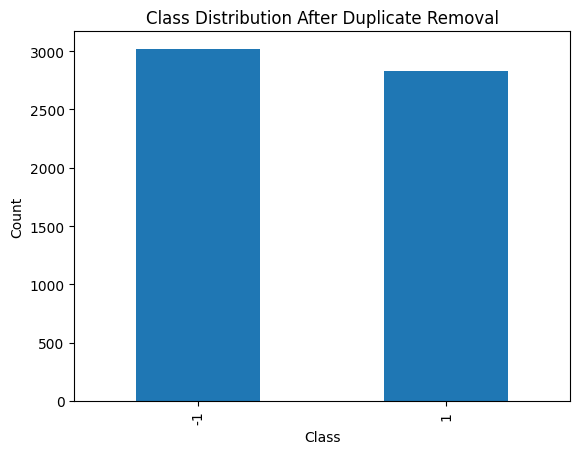

In [16]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')

plt.title("Class Distribution After Duplicate Removal")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Correlation Analysis

In [17]:
correlations = df_no_dup.corr()['class'].sort_values(ascending=False)

print(correlations)

class                  1.000000
HTTPS                  0.693228
AnchorURL              0.679125
PrefixSuffix-          0.381134
SubDomains             0.296214
WebsiteTraffic         0.281709
ServerFormHandler      0.281131
LinksInScriptTags      0.243864
RequestURL             0.237778
GoogleIndex            0.118217
StatsReport            0.108486
UsingIP                0.104952
LinksPointingToPage    0.068463
AgeofDomain            0.062800
LongURL                0.058228
PageRank               0.048140
Symbol@                0.034757
DNSRecording           0.033204
NonStdPort             0.014201
StatusBarCust          0.012790
DisableRightClick      0.009286
InfoEmail             -0.008014
IframeRedirection     -0.011756
UsingPopupWindow      -0.022455
Favicon               -0.025457
Redirecting//         -0.036693
WebsiteForwarding     -0.037462
HTTPSDomainURL        -0.051412
ShortURL              -0.076166
AbnormalURL           -0.090043
DomainRegLen          -0.218623
Name: cl

In [18]:
print(correlations.head(10))

class                1.000000
HTTPS                0.693228
AnchorURL            0.679125
PrefixSuffix-        0.381134
SubDomains           0.296214
WebsiteTraffic       0.281709
ServerFormHandler    0.281131
LinksInScriptTags    0.243864
RequestURL           0.237778
GoogleIndex          0.118217
Name: class, dtype: float64


## Top Feature Correlations

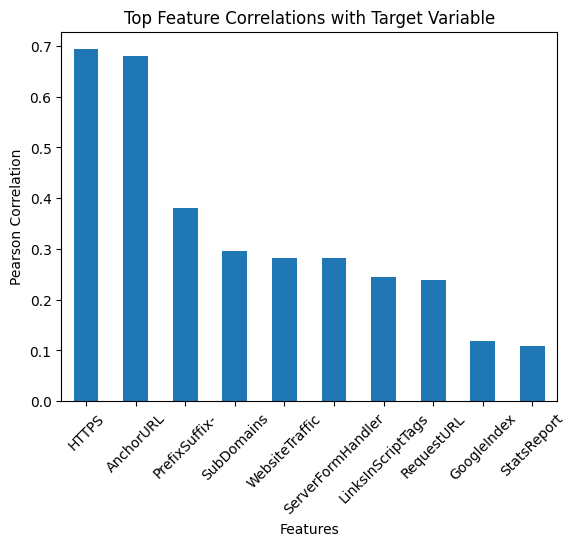

In [19]:
import matplotlib.pyplot as plt

top_features = correlations.drop('class').head(10)

top_features.plot(kind='bar')

plt.title("Top Feature Correlations with Target Variable")
plt.xlabel("Features")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=45)

plt.show()